# Stage 11 Homework — Evaluation & Risk Communication

In [12]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install pandas
# !pip install matplotlib

In [13]:
# Setup
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(_root))
from src import evaluation as ev

SEED = 111
np.random.seed(SEED)
plt.rcParams["figure.figsize"] = (8, 5)

## Load Data (provided or synthetic fallback)

In [14]:
df = pd.read_csv(_root / "data" / "raw" / "card_tiers.csv")
df["x_feature"] = np.log10(df["odds_pack"])       # NaN kept
df["y_target"]  = np.log10(df["est_value_usd"])
df["segment"]   = df["tier_group"]
x_raw = df["x_feature"].values
y = df["y_target"].values
print(f"n={len(df)}  |  NaN in x: {np.isnan(x_raw).sum()} ({np.isnan(x_raw).mean():.1%})")
df[["segment", "tier_name", "x_feature", "y_target"]].head()

n=194  |  NaN in x: 13 (6.7%)


,segment,tier_name,x_feature,y_target
0,base,Base,NaN,-0.301030
1,parallel,Base Refractor,0.477121,0.477121
2,parallel,Prism Refractor,0.698970,0.477121
3,parallel,Wave Refractor,1.146128,0.477121
4,parallel,Negative Refractor,1.491362,0.903090


## Helper functions — `src/evaluation.py`

Imported as `ev`: `mean_impute` / `median_impute`, `ols` / `predict`, `mae` / `rmse`,
`gaussian_pred_ci`, `bootstrap_pred_band`, `bootstrap_metric`, `scenario_table`,
`subgroup_residuals`. This is the Stage 11 deliverable — the notebook only calls them.

## Baseline Fit & Residuals (Required)

In [15]:
x_base = ev.mean_impute(x_raw)
b0, b1 = ev.ols(x_base, y)
y_hat = ev.predict(x_base, b0, b1)
df["x_imputed"], df["y_hat"] = x_base, y_hat
df["resid"] = y - y_hat
print(f"slope={b1:.3f}  intercept={b0:.3f}  "
      f"MAE={ev.mae(y, y_hat):.4f}  RMSE={ev.rmse(y, y_hat):.4f}  (log10 USD)")

slope=0.669  intercept=0.095  MAE=0.3190  RMSE=0.5057  (log10 USD)


## Gaussian-based vs Bootstrap-based CI (Required)

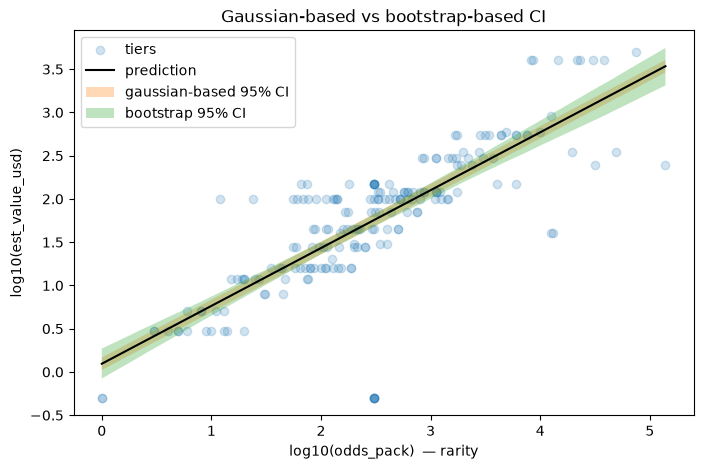

gaussian half-width (flat): 0.0714
bootstrap band width:  center 0.1455   edges 0.3895


In [16]:
x_grid = np.linspace(np.nanmin(x_base), np.nanmax(x_base), 120)
pred_line = ev.predict(x_grid, b0, b1)
g_lo, g_hi = ev.gaussian_pred_ci(df["resid"].values, pred_line, n=len(y))
m_boot, lo_boot, hi_boot = ev.bootstrap_pred_band(x_base, y, x_grid, n_boot=600, seed=SEED)

plt.figure()
plt.scatter(x_base, y, alpha=0.20, label="tiers")
plt.plot(x_grid, pred_line, color="k", label="prediction")
plt.fill_between(x_grid, g_lo, g_hi, alpha=0.30, label="gaussian-based 95% CI")
plt.fill_between(x_grid, lo_boot, hi_boot, alpha=0.30, label="bootstrap 95% CI")
plt.xlabel("log10(odds_pack)  — rarity"); plt.ylabel("log10(est_value_usd)")
plt.title("Gaussian-based vs bootstrap-based CI"); plt.legend(); plt.show()

print(f"gaussian half-width (flat): {(g_hi-g_lo).mean()/2:.4f}")
print(f"bootstrap band width:  center {(hi_boot-lo_boot)[60]:.4f}   "
      f"edges {(hi_boot-lo_boot)[[0,-1]].mean():.4f}")

## Scenario Sensitivity (Required): Choose ≥2 Scenarios
Examples: mean vs median impute; drop; alternate feature transform

In [17]:
sens = ev.scenario_table(x_raw, y, {"mean_impute": "mean",
                                   "median_impute": "median",
                                   "drop_missing": "drop"})
(_root / "data" / "processed").mkdir(parents=True, exist_ok=True)
sens.to_csv(_root / "data" / "processed" / "scenario_results.csv", index=False)
sens.round(4)

,scenario,n,slope,intercept,mae
0,mean_impute,194,0.6688,0.0949,0.3190
1,median_impute,194,0.6700,0.0929,0.3187
2,drop_missing,181,0.6688,0.1475,0.2540


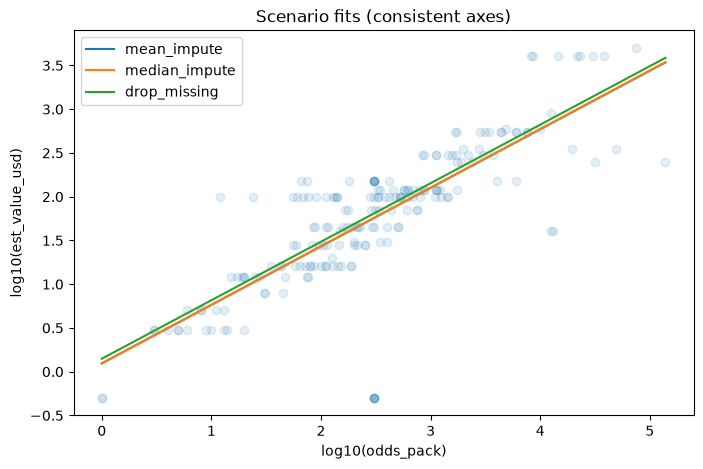

In [18]:
plt.figure()
xg = np.linspace(np.nanmin(x_base), np.nanmax(x_base), 150)
for name, how in {"mean_impute": "mean", "median_impute": "median", "drop_missing": "drop"}.items():
    if how == "drop":
        m = ~np.isnan(x_raw); xi, yi = x_raw[m], y[m]
    else:
        xi = ev.mean_impute(x_raw) if how == "mean" else ev.median_impute(x_raw); yi = y
    c0, c1 = ev.ols(xi, yi)
    plt.plot(xg, ev.predict(xg, c0, c1), label=name)
plt.scatter(x_base, y, alpha=0.12)
plt.xlabel("log10(odds_pack)"); plt.ylabel("log10(est_value_usd)")
plt.title("Scenario fits (consistent axes)"); plt.legend(); plt.show()

## Subgroup Diagnostic (Required)

In [19]:
g = ev.subgroup_residuals(df, "segment", "resid")
g.round(3)

,mean,std,median,count
segment,,,,
auto,0.228,0.438,0.220,47
base,-1.639,0.768,-2.054,8
insert,0.020,0.234,0.023,28
parallel,0.039,0.273,0.025,108
variation,-0.808,0.745,-1.232,3


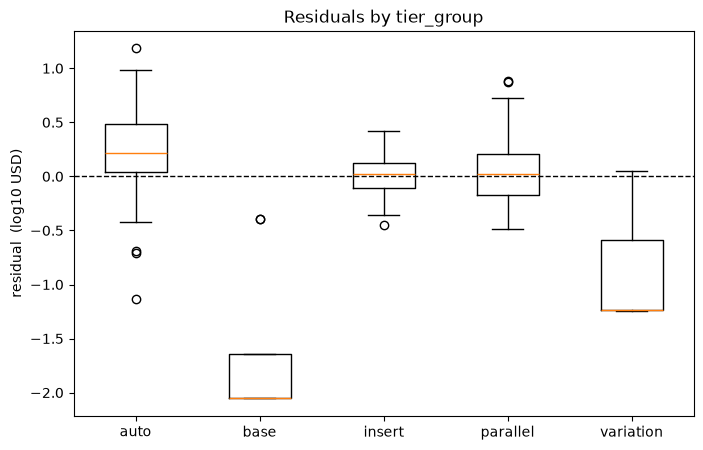

In [20]:
plt.figure()
grp = df.groupby("segment")["resid"]
labels = list(grp.groups)
plt.boxplot([s.values for _, s in grp])
plt.xticks(range(1, len(labels) + 1), labels)
plt.axhline(0, ls="--", color="k", lw=1)
plt.ylabel("residual  (log10 USD)")
plt.title("Residuals by tier_group")
plt.show()

## Bootstrap a Metric (Required)

In [21]:
bm = ev.bootstrap_metric(y, y_hat, ev.mae, n_boot=600, seed=SEED)
bm

{'mean': 0.3209860624728722,
 'lo': 0.2700457063364756,
 'hi': 0.3800075055759814}

## Stakeholder Summary

**Model.** One-line rule: a tier's value scales with its rarity —
`log10(value) = 0.10 + 0.67 * log10(odds_pack)`, i.e. **every 10x rarer ~ 4.7x more
valuable**. Held-out-style MAE is **0.32 in log10-USD** (a typical miss of ~2x),
bootstrap 95% CI **[0.27, 0.38]**.

**Key assumptions.**
1. `est_value_usd` is the `rough_estimate_v0` placeholder ladder for 188 / 194 tiers —
   the model is fit to a formula, not the market. Everything here is provisional.
2. One feature (rarity). Card value is really set by *which player* is on the card;
   that isn't in the data yet.
3. Linear in log-log space, homoscedastic, independent rows.

**Sensitivity — does the conclusion move?**
| scenario | slope | MAE |
|---|---|---|
| mean-impute missing odds | 0.669 | 0.319 |
| median-impute | 0.670 | 0.319 |
| drop the 13 unpublished-odds tiers | 0.669 | 0.254 |

The **slope is rock-stable** across all three — the imputation choice does not change the
rarity->value relationship. Dropping the 13 tiers only lowers MAE (it removes rows the
odds-only line was never going to fit: SSP inserts whose true odds are unknown). *The
answer is not sensitive to how missing odds are handled.*

**Uncertainty.** The gaussian CI is a flat +/-0.07 band; the bootstrap band is ~0.15 wide
in the middle but **~0.43 at the extremes** (very common and very rare tiers), where data
is thin. Trust the model least for the rarest chase tiers — exactly the ones that drive
box EV.

**Subgroup risk.** Residual means by tier type:
- `auto` **+0.23** — the model **under-values autographs** (~1.7x low).
- `base` **-1.6**, `variation` **-0.8** — badly **over-valued** (the line can't reach
  $0.50 commons).
- `parallel` +0.04, `insert` +0.02 — well-calibrated (67% of tiers).

So the odds-only line works for the refractor rainbow but is systematically off for autos
(low) and base/variation (high).

**Decision framing.**
- *The prediction holds if* the tier is a numbered parallel or insert of a mid-tier
  subject, in the mid rarity range.
- *The model is sensitive to* the placeholder target and the missing player dimension —
  not to imputation method.
- *Do not* feed these values into the buy/pass EV calc yet.

**If this were live — monitoring.** Track model MAE against incoming real eBay comps
weekly; alert if the auto-tier residual bias grows or the rarity slope drifts outside
~[0.55, 0.80]; re-fit whenever a new product's checklist lands.